In [1]:
!pip install librosa soundfile -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import os
import zipfile
import urllib.request
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# RAVDESS speech dataset - hosted on Zenodo (official, reliable)
url = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
zip_path = "ravdess.zip"

print("Downloading RAVDESS dataset (~200MB, may take a few minutes)...")
urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("ravdess_data")

print("Download complete!")
print(os.listdir("ravdess_data")[:5])

Download complete!
['Actor_01', 'Actor_19', 'Actor_10', 'Actor_07', 'Actor_06']


In [4]:
# RAVDESS filename format: 03-01-06-01-02-01-12.wav
# Position 3 = emotion code:
# 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised

emotion_map = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}

# Collect all file paths
data_dir = "ravdess_data"
file_paths = []
emotions = []

for actor_folder in os.listdir(data_dir):
    actor_path = os.path.join(data_dir, actor_folder)
    if os.path.isdir(actor_path):
        for filename in os.listdir(actor_path):
            if filename.endswith(".wav"):
                parts = filename.split("-")
                emotion_code = parts[2]
                emotions.append(emotion_map[emotion_code])
                file_paths.append(os.path.join(actor_path, filename))

df = pd.DataFrame({"path": file_paths, "emotion": emotions})
print(df.shape)
print(df["emotion"].value_counts())

(1440, 2)
emotion
sad          192
happy        192
calm         192
disgust      192
angry        192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


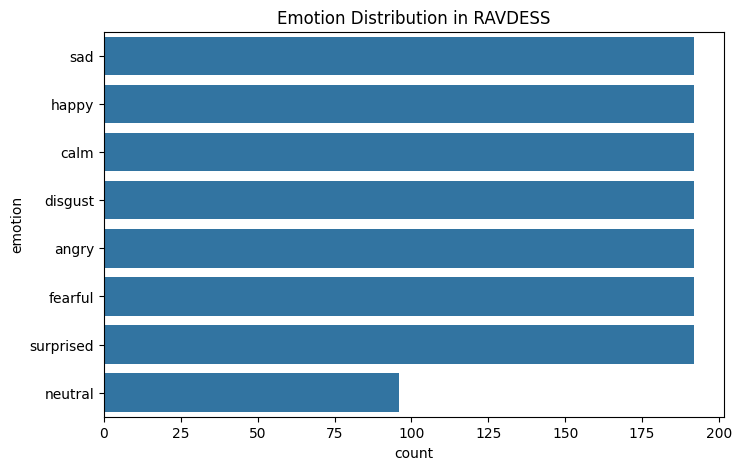

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(y="emotion", data=df, order=df["emotion"].value_counts().index)
plt.title("Emotion Distribution in RAVDESS")
plt.show()

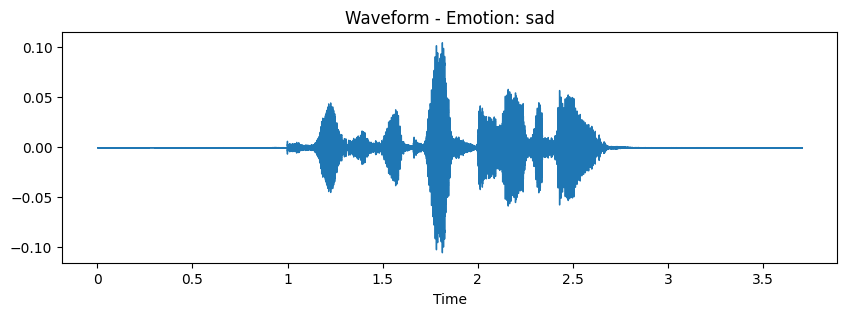

In [6]:
sample_path = df["path"].iloc[0]
y_audio, sr = librosa.load(sample_path, sr=22050)

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y_audio, sr=sr)
plt.title(f"Waveform - Emotion: {df['emotion'].iloc[0]}")
plt.show()

# Play audio (works in Colab)
import IPython.display as ipd
ipd.Audio(sample_path)

In [7]:
def extract_mfcc(file_path, n_mfcc=40):
    y_audio, sr = librosa.load(file_path, sr=22050, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    return mfcc_mean

print("Extracting MFCC features from all audio files...")
features = []
for path in df["path"]:
    features.append(extract_mfcc(path))

X = np.array(features)
print("Feature matrix shape:", X.shape)

Extracting MFCC features from all audio files...
Feature matrix shape: (1440, 40)


In [8]:
le = LabelEncoder()
y_encoded = le.fit_transform(df["emotion"])
num_classes = len(le.classes_)
print("Classes:", le.classes_)

y_cat = to_categorical(y_encoded, num_classes)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)
print(X_train.shape, X_test.shape)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
(1152, 40) (288, 40)


In [9]:
model = models.Sequential([
    layers.Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,168 (203.78 KB)

 Trainable params: 52,168 (203.78 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32
)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1931 - loss: 2.0153 - val_accuracy: 0.2586 - val_loss: 1.9080
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3031 - loss: 1.8284 - val_accuracy: 0.3017 - val_loss: 1.7918
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3581 - loss: 1.7064 - val_accuracy: 0.3448 - val_loss: 1.6964
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4073 - loss: 1.5741 - val_accuracy: 0.3621 - val_loss: 1.6298
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4324 - loss: 1.4916 - val_accuracy: 0.3621 - val_loss: 1.6452
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4913 - loss: 1.3791 - val_accuracy: 0.4138 - val_loss: 1.4816
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5164 - loss: 1.3062 - val_accuracy: 0.4224 - val_loss: 1.4033
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5357 - loss: 1.2371 - val_accuracy: 0.4397 - val_loss

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6736 - loss: 1.2194 
Test Accuracy: 0.6736


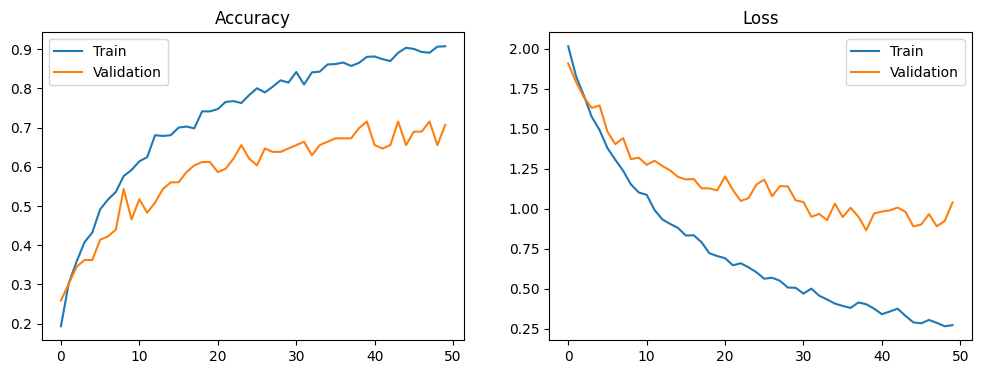

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss")
axes[1].legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


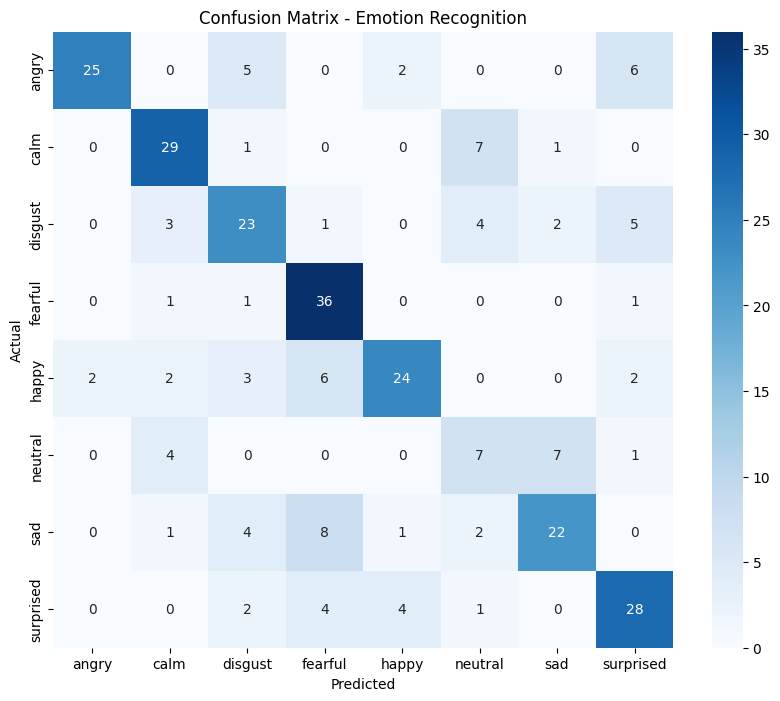

              precision    recall  f1-score   support

       angry       0.93      0.66      0.77        38
        calm       0.72      0.76      0.74        38
     disgust       0.59      0.61      0.60        38
     fearful       0.65      0.92      0.77        39
       happy       0.77      0.62      0.69        39
     neutral       0.33      0.37      0.35        19
         sad       0.69      0.58      0.63        38
   surprised       0.65      0.72      0.68        39

    accuracy                           0.67       288
   macro avg       0.67      0.65      0.65       288
weighted avg       0.69      0.67      0.67       288



In [12]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Emotion Recognition")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

In [13]:
model.save("emotion_recognition_model.h5")
import joblib
joblib.dump(scaler, "emotion_scaler.pkl")
joblib.dump(le, "emotion_label_encoder.pkl")
print("Model saved successfully!")

Model saved successfully!
